# Netflix Content Structure Analysis

## Project Objective

The purpose of this project is to analyze the structural composition of Netflix’s content catalog.

The analysis focuses on:
- Content duration patterns
- TV show seasonal structure
- Genre distribution
- Production and acquisition characteristics



## Dataset Information

The dataset contains metadata about Netflix Movies and TV Shows, including title, type, cast, director, country, genre, release year, duration, etc.

Source: Kaggle – Netflix Movies and TV Shows Dataset.
https://www.kaggle.com/datasets/shivamb/netflix-shows


#### Main Data Fields


| Column          | Description                   |
|:-------------------|:----------------------------------|
| **show_id**  | 	Unique identifier for each title     |
| **type**         | Movie or TV Show    |
| **title**       | Title name        |
| **director**  | Director(s) of the title     |
| **cast**  | Main cast members     |
| **country**  | Production country     |
| **date_added**  | Date added to platform     |
| **release_year**  | Year of release     |
| **rating**  | Content rating     |
| **duration**  | Movie duration (minutes) or number of seasons     |
| **listed_in**  | Genre categories     |
| **description**  | Short content description     |


# 1. Dataset Overview


In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/Data_Analyst/Фінальний прект/netflix_titles.csv')

# Display the first few rows of the DataFrame to inspect the data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Display the shape of the DataFrame (number of rows and columns)
df.shape
# Display concise summary of the DataFrame, including data types and non-null values
df.info()
# Generate descriptive statistics of the DataFrame, including all columns
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN



# 2. Data Cleaning


In [ ]:
# Remove duplicate rows from the DataFrame to ensure data uniqueness
df = df.drop_duplicates()

In [ ]:
# Calculate the number of missing values for each column
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
# Fill missing 'director', 'cast' and 'country' values with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [ ]:
# Convert the 'date_added' column to datetime objects, coercing errors to NaT
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [ ]:
# Generate descriptive statistics of the DataFrame after cleaning, including all columns
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8709,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4529,7693,749,NaN,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,NaN,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-23 01:45:29.452290816,2014.180198,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-20 00:00:00,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-12 00:00:00,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-26 00:00:00,2019.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN


In [ ]:
# Display rows where 'duration' column has missing values
df[df['duration'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [ ]:
# Create a mask for rows where 'duration' is NaN and 'rating' contains 'min'
mask = df['duration'].isna() & df['rating'].str.contains('min', na=False)

# Transfer values from 'rating' to 'duration' for the identified rows
df.loc[mask, 'duration'] = df.loc[mask, 'rating']

# Set 'rating' to NaN for the identified rows as the value was incorrectly stored there
df.loc[mask, 'rating'] = np.nan

Before feature engineering, the dataset was checked for column misalignment issues.
Several records were identified where duration values were incorrectly stored in the rating column.
These inconsistencies were corrected before further processing.

In [ ]:
# Create new columns for duration in minutes and seasons, initialized with appropriate data types
df['duration_minutes'] = pd.Series(dtype='Int64')
df['duration_seasons'] = pd.Series(dtype='Int64')

# Process movies: extract numerical duration (minutes) and convert to Int64
movies = df['type'] == 'Movie'
df.loc[movies, 'duration_minutes'] = (
    df.loc[movies, 'duration']
      .str.extract(r'(\d+)')[0] # Extract digits
      .astype('Int64')
)

# Process TV shows: extract numerical duration (seasons) and convert to Int64
tv_shows = df['type'] == 'TV Show'
df.loc[tv_shows, 'duration_seasons'] = (
    df.loc[tv_shows, 'duration']
      .str.extract(r'(\d+)')[0] # Extract digits
      .astype('Int64')
)

# Separate DataFrames for movies and TV shows
movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

# Verify the new duration columns
df[['type', 'duration', 'duration_minutes', 'duration_seasons']].head()

,type,duration,duration_minutes,duration_seasons
0,Movie,90 min,90,<NA>
1,TV Show,2 Seasons,<NA>,2
2,TV Show,1 Season,<NA>,1
3,TV Show,1 Season,<NA>,1
4,TV Show,2 Seasons,<NA>,2


# 3. Exploratory Data Analysis


In [ ]:
# Define Netflix color palette for consistent visualization
netflix_red = "#E50914"
dark_gray = "#221F1F"
mid_gray    = "#564D4D"
light_gray = "#B3B3B3"

## **Platform Identity & Content Positioning (Block 1)**

**Key Questions:**

* Is the platform primarily movie-driven or series-driven?

* Does the platform target mature audiences more than children or families?

* What genres define the platform’s core identity?




### Content Type Distribution

In [ ]:
# Calculate the counts of each content type (Movie/TV Show)
type_counts = df['type'].value_counts()
# Calculate the percentage distribution of each content type
type_percent = df['type'].value_counts(normalize=True) * 100

# Combine counts and percentages into a summary DataFrame
type_summary = pd.DataFrame({
    'Count': type_counts,
    'Percentage': type_percent.round(2)
})

# Display the summary DataFrame
type_summary

,Count,Percentage
type,,
Movie,6131,69.62
TV Show,2676,30.38


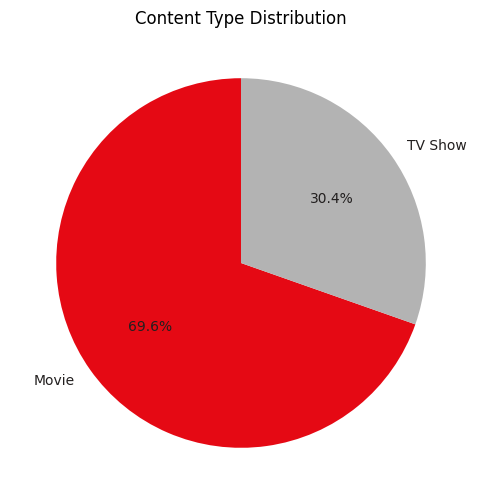

In [ ]:
# Get the counts of each content type
type_counts = df['type'].value_counts()

# Create a pie chart to visualize the distribution of content types
plt.figure(figsize=(6,6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[netflix_red, light_gray],
    textprops={'color': dark_gray},
)
plt.title('Content Type Distribution')
plt.show()

Movies dominate the platform, making up almost 70% of all content, while TV Shows represent about 30%. This indicates a clear preference for film-based content.



### Rating × Type

In [ ]:
# Create a cross-tabulation of 'rating' and 'type' to see distribution of content types by rating
rating_type = pd.crosstab(df['rating'], df['type'])
# Display the cross-tabulation
rating_type

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94
TV-MA,2062,1145


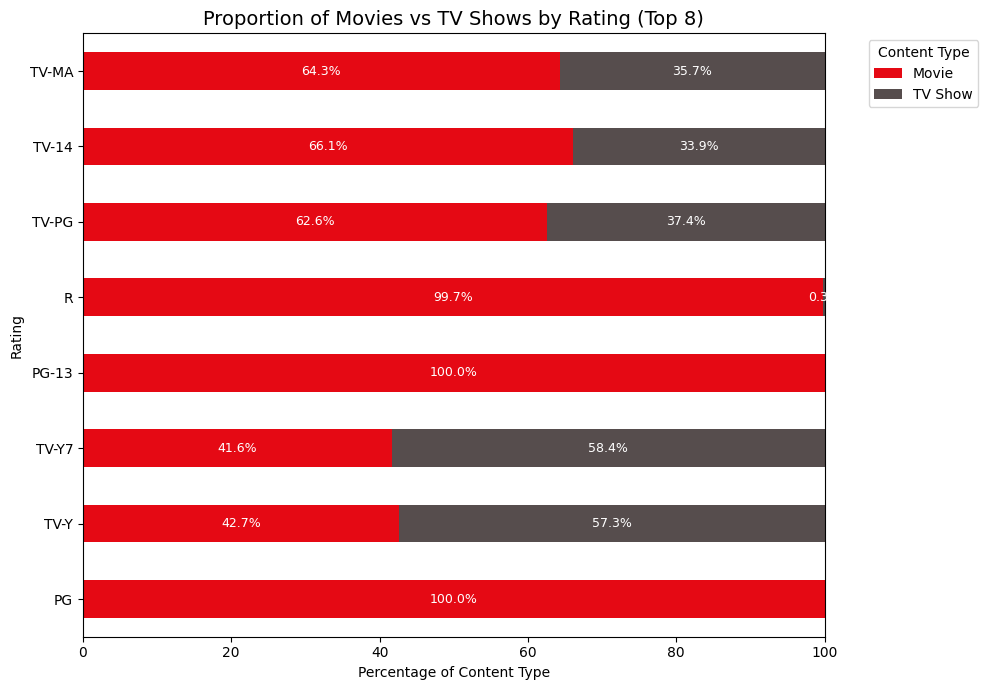

In [ ]:
# Get the top 8 most frequent ratings for better readability in the plot
top_ratings = df['rating'].value_counts().head(8).index
# Filter the crosstab to include only the top ratings
rating_type = pd.crosstab(df['rating'], df['type']).loc[top_ratings]
# Calculate the total count for each rating
rating_type['total'] = rating_type['Movie'] + rating_type['TV Show']
# Sort the ratings by their total count in descending order and remove the 'total' column
rating_type = rating_type.sort_values(by='total', ascending=False).drop(columns='total')

# Convert counts to percentages for a 100% stacked bar chart
rating_type_percent = rating_type.div(rating_type.sum(axis=1), axis=0) * 100

# Create a horizontal stacked bar chart
plt.figure(figsize=(10, 7))
ax = rating_type_percent.plot(kind='barh', stacked=True, ax=plt.gca(),
                               color=[netflix_red, mid_gray])

plt.title("Proportion of Movies vs TV Shows by Rating (Top 8)", fontsize=14)
plt.xlabel("Percentage of Content Type")
plt.ylabel("Rating")
plt.legend(title='Content Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{p.get_width():.1f}%' if p.get_width() > 0 else '' for p in container.patches]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white')

plt.xlim(0, 100)
plt.gca().invert_yaxis() # Invert y-axis for better readability (highest at top)
plt.tight_layout()
plt.show()

The cross-analysis shows that Movies dominate most rating categories, especially in cinema-style ratings such as PG, PG-13, and R, which are almost entirely composed of films. This shows that traditional cinema-style content on the platform is mainly delivered through movies.

TV Shows are mostly concentrated in TV-specific ratings and are relatively stronger in kids categories like TV-Y and TV-Y7. In simple terms, movies cover a wider range of age levels, while TV Shows are more limited in ratings and play a bigger role in children’s episodic content.

### Top 10 Genres

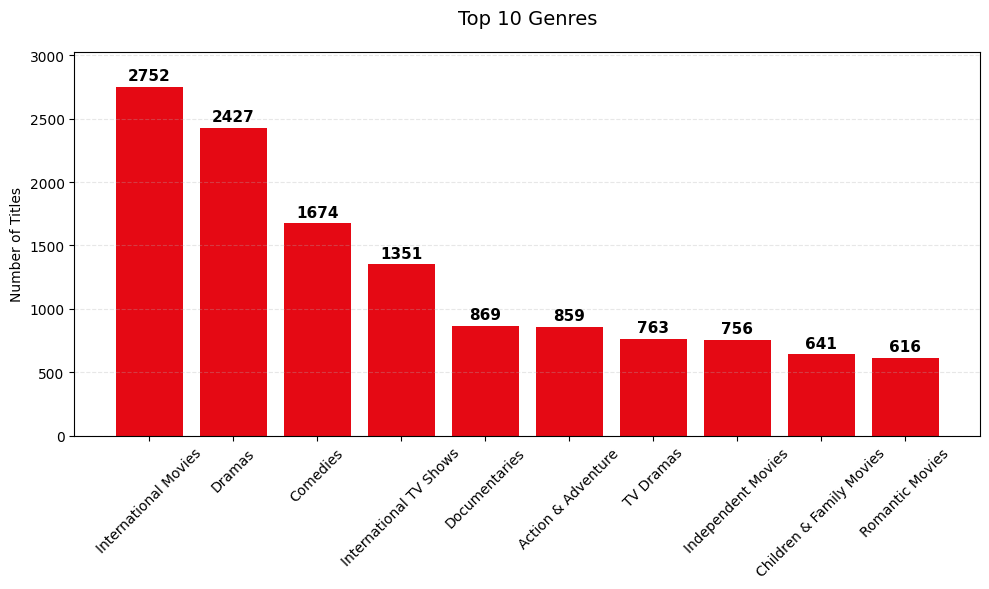

In [ ]:
# Split the 'listed_in' column (genres) by ', ' and expand into separate rows
all_genres = df['listed_in'].str.split(', ').explode()

# Count the occurrences of each genre and get the top 10
top_genres = all_genres.value_counts().head(10)

# Create a bar plot for the top 10 genres
plt.figure(figsize=(10, 6))
plt.bar(top_genres.index, top_genres.values, color=netflix_red)

# Add value labels on top of each bar
for i, value in enumerate(top_genres.values):
    plt.text(i, value + (top_genres.max() * 0.01), str(value),
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, top_genres.max() * 1.1) # Adjust y-axis limit for labels
plt.title('Top 10 Genres', pad=20, fontsize=14)
plt.xticks(rotation=45) # Rotate x-axis labels for readability
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The platform's content strategy heavily leans towards a global audience, with 'International Movies' and 'Dramas' dominating the top genres. This indicates a strong focus on mature storytelling and diverse global narratives. While also offering substantial 'Comedies' and 'Action & Adventure', the platform prioritizes adult-oriented, often dramatic, content, with children's content playing a lesser role.

###
**Block 1 Conclusion**

Overall, the platform appears to be film-heavy, maturity-oriented, and strongly positioned around mainstream entertainment genres. The structural dominance of movies and adult ratings suggests a strategy focused on broad commercial appeal rather than niche or purely family-oriented content.

## **Growth Dynamics & Strategic Shift (Block 2)**

Key Questions:

* When did the platform experience rapid growth?

* Did the growth accelerate after 2015 (streaming boom hypothesis)?

* Has the balance between Movies and TV Shows changed over time?

* Is the platform adding mostly recent releases or older archived content?

### Titles Added Per Year

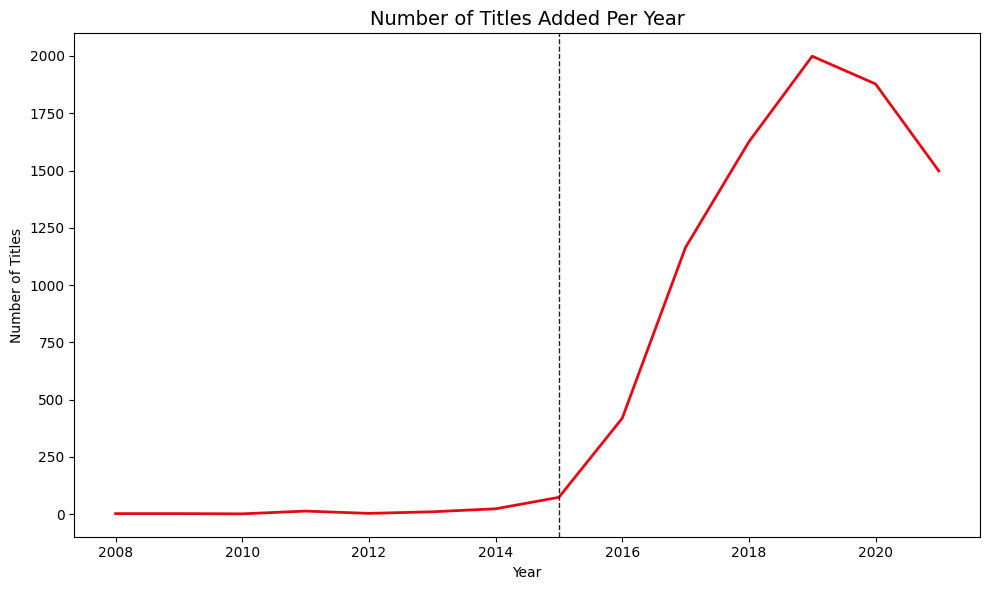

In [ ]:
# Extract the year from the 'date_added' column and store it in a new column
df['date_added_year'] = df['date_added'].dt.year

# Group by 'date_added_year' and count the number of titles added each year
titles_per_year = (
    df.dropna(subset=['date_added_year']) # Drop rows where 'date_added_year' is NaN
      .groupby('date_added_year')
      .size()
)

# Create a line plot to visualize the number of titles added per year
plt.figure(figsize=(10,6))

plt.plot(titles_per_year.index,
         titles_per_year.values,
         color=netflix_red,
         linewidth=2)

# Add a vertical line at the year 2015 for context
plt.axvline(2015, color=dark_gray, linestyle='--', linewidth=1)

plt.title("Number of Titles Added Per Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

After 2015, the number of titles added to Netflix increased dramatically, indicating a period of rapid platform expansion. The growth peaked around 2019, suggesting maximum content acquisition during that phase. A slight decline after 2019 may reflect market saturation or strategic content optimization.

### Movies vs TV Shows Over Time

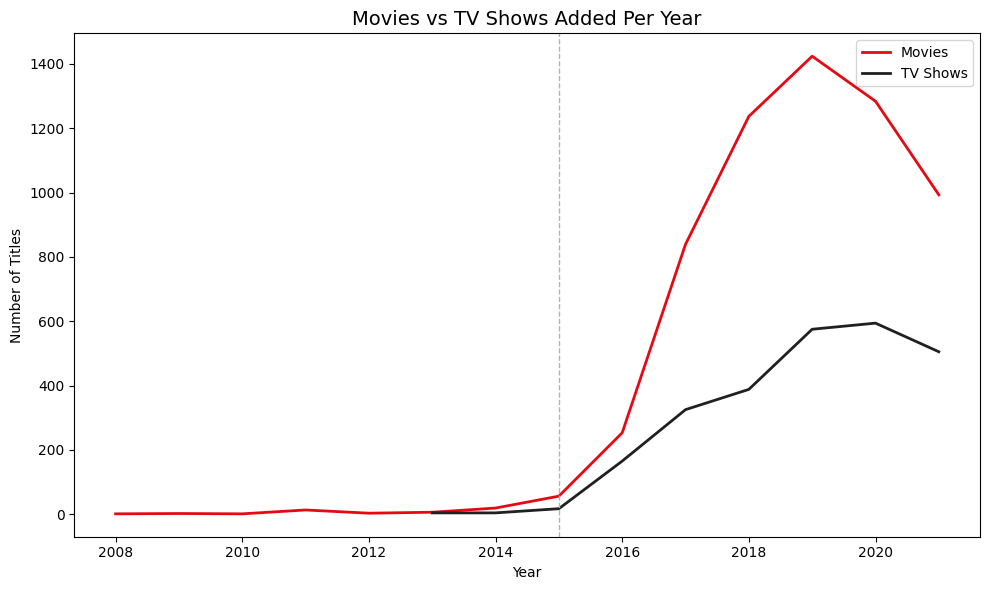

In [ ]:
# Group data by 'date_added_year' and 'type' and count titles, then unstack to separate Movie/TV Show counts
type_year = (
    df.dropna(subset=['date_added_year'])
      .groupby(['date_added_year', 'type'])
      .size()
      .unstack()
)

# Create a line plot to show Movies vs TV Shows added per year
plt.figure(figsize=(10,6))

plt.plot(type_year.index,
         type_year['Movie'],
         label='Movies',
         color=netflix_red,
         linewidth=2)

plt.plot(type_year.index,
         type_year['TV Show'],
         label='TV Shows',
         color=dark_gray,
         linewidth=2)

# Add a vertical line at the year 2015 for context
plt.axvline(2015, color=light_gray, linestyle='--', linewidth=1)

plt.title("Movies vs TV Shows Added Per Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend()

plt.tight_layout()
plt.show()

Both Movies and TV Shows increased significantly after 2015, but Movies consistently dominated in absolute numbers. However, TV Shows demonstrated strong and steady growth, especially between 2016 and 2019. This suggests a strategic shift toward serialized content while maintaining a strong movie catalog.

### Type Share Over Time

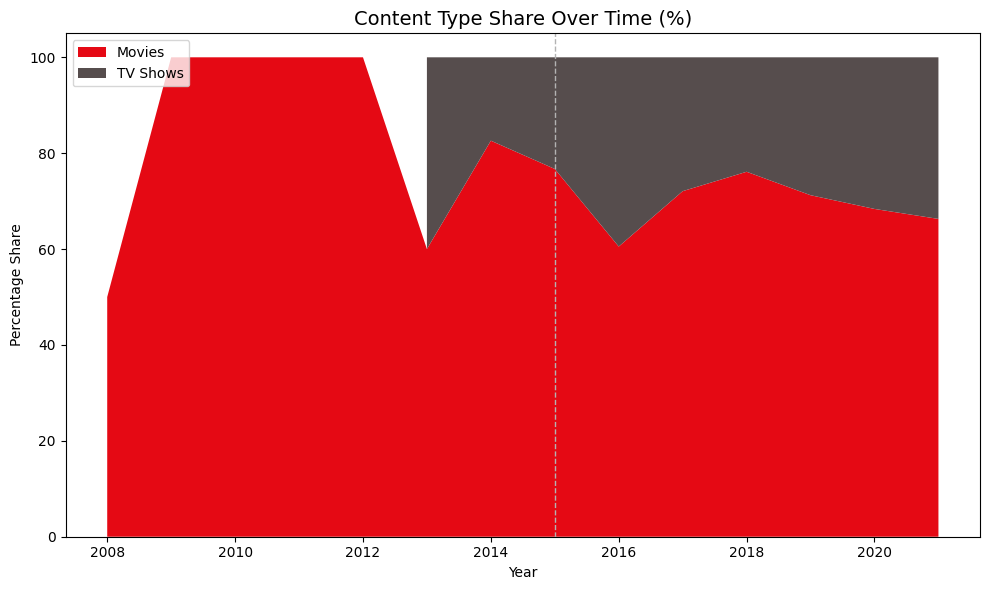

In [ ]:
# Group data by 'date_added_year' and 'type' and count titles, then unstack
type_share = (
    df.dropna(subset=['date_added_year'])
      .groupby(['date_added_year', 'type'])
      .size()
      .unstack()
)

# Calculate the percentage share of Movies and TV Shows for each year
type_share_pct = type_share.div(type_share.sum(axis=1), axis=0) * 100

# Create a stacked area plot to visualize content type share over time
plt.figure(figsize=(10,6))

plt.stackplot(
    type_share_pct.index,
    type_share_pct['Movie'],
    type_share_pct['TV Show'],
    labels=['Movies', 'TV Shows'],
    colors=[netflix_red, mid_gray]
)

# Add a vertical line at the year 2015 for context
plt.axvline(2015, color=light_gray, linestyle='--', linewidth=1)

plt.title("Content Type Share Over Time (%)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Percentage Share")
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Although Movies consistently hold the majority share, the proportion of TV Shows increases notably after 2014. This indicates a structural shift in Netflix’s content strategy toward serialized formats. The platform gradually diversifies its catalog rather than relying predominantly on movies.

### Content Age

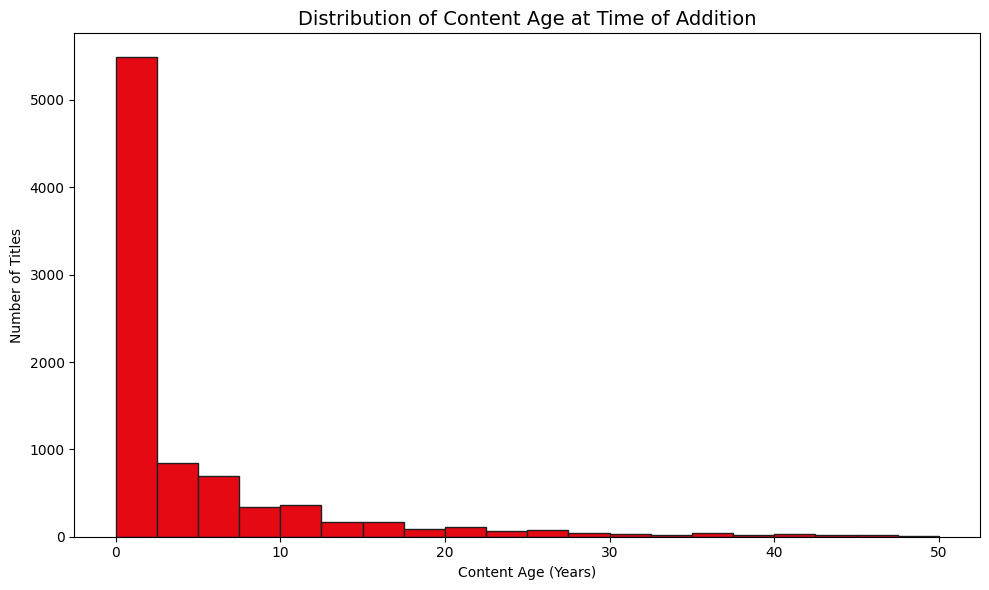

In [ ]:
# Calculate the age of content (years since release when added to Netflix)
df['content_age'] = df['date_added_year'] - df['release_year']
# Filter for valid content ages (non-negative and within a reasonable range)
content_age_clean = df[
    (df['content_age'] >= 0) &
    (df['content_age'] <= 50) # Assuming 50 years is a reasonable upper bound for age
]['content_age']

# Create a histogram to visualize the distribution of content age
plt.figure(figsize=(10,6))

plt.hist(content_age_clean,
         bins=20,
         color=netflix_red,
         edgecolor=dark_gray)

plt.title("Distribution of Content Age at Time of Addition", fontsize=14)
plt.xlabel("Content Age (Years)")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

The distribution is heavily right-skewed, with a strong concentration of titles added within 0–2 years after release. This suggests that Netflix prioritizes relatively recent content. However, the long tail of older titles indicates a complementary strategy of maintaining a diverse back-catalog.

###
**Block 2 Conclusion**

Netflix experienced rapid catalog expansion after 2015, marking a clear growth phase in platform development. While Movies remain dominant in absolute and relative terms, the increasing share of TV Shows reflects a strategic pivot toward serialized content consumption. Additionally, the predominance of recently released titles suggests a focus on freshness and competitiveness, complemented by a selective inclusion of older content to preserve catalog depth.

## **Geographic Structure & Global Expansion (Block 3)**

Key Questions:

* Which countries contribute most to Netflix’s catalog, and how is production structured by content type?

* Has Netflix become more geographically diversified over time?

* Is Netflix reducing its reliance on U.S. production over time?

* Which markets are driving Netflix’s recent expansion?


### Top Producing Countries

In [ ]:
# Split the 'country' column by comma and explode into separate rows for each country
country_series = (
    df['country']
    .str.split(',')
    .explode()
    .str.strip()
)

# Count the occurrences of each country (excluding 'Unknown') and get the top 10
top_countries = (
    country_series[country_series != 'Unknown']
    .value_counts()
    .head(10)
)

# Display the top producing countries
top_countries

,count
country,
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


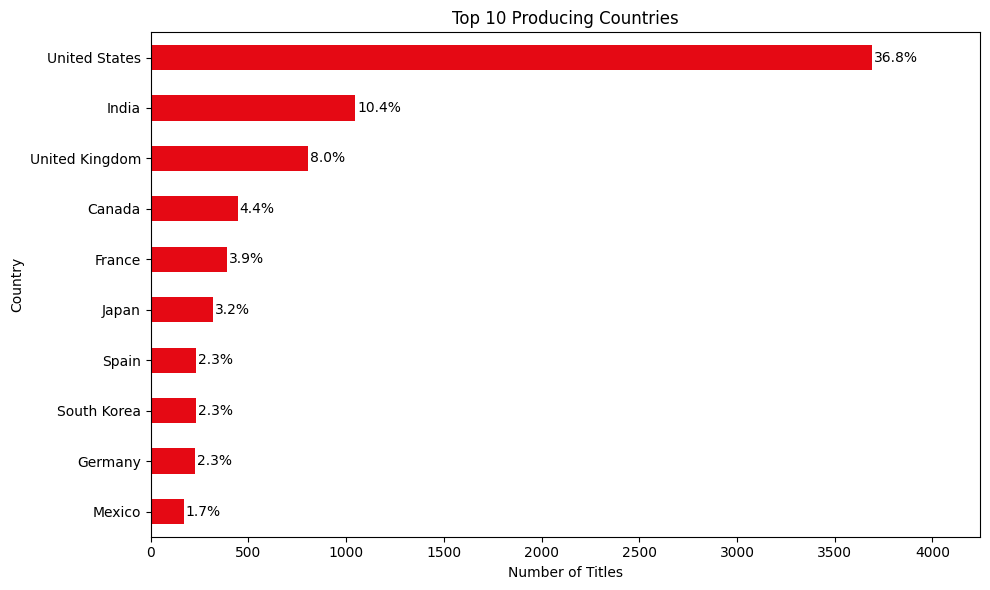

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the top countries as a horizontal bar chart, sorted by count
top_countries.sort_values().plot(kind='barh', color=netflix_red, ax=ax)

# Calculate total non-unknown country entries for percentage calculation
total = country_series[country_series != 'Unknown'].count()
# Add percentage labels to each bar
for p in ax.patches:
    pct = p.get_width() / total * 100
    ax.text(p.get_width() + 10, p.get_y() + p.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=10)

ax.set_xlim(0, top_countries.max() * 1.15) # Adjust x-axis limit for labels
ax.set_title("Top 10 Producing Countries")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

The United States clearly dominates production, accounting for more than one-third of all titles. India and the United Kingdom follow but at significantly lower levels.

### Movies vs TV Shows by Country

In [ ]:
# Create a copy of the DataFrame
df_country = df.copy()
# Split the 'country' column into a list of countries
df_country['country'] = df_country['country'].str.split(', ')
# Explode the list of countries into separate rows
df_country_exploded = df_country.explode('country')

# Group by 'country' and 'type' to count movies and TV shows per country
country_type = (
    df_country_exploded
    .groupby(['country', 'type'])
    .size()
    .unstack(fill_value=0) # Unstack 'type' to create 'Movie' and 'TV Show' columns
)

# Filter for the top producing countries identified earlier
country_type_top = country_type.loc[top_countries.index]
# Display the counts of movies and TV shows for top countries
country_type_top

type,Movie,TV Show
country,,
United States,2751,938
India,962,84
United Kingdom,532,272
Canada,319,126
France,303,90
Japan,119,199
Spain,171,61
South Korea,61,170
Germany,182,44


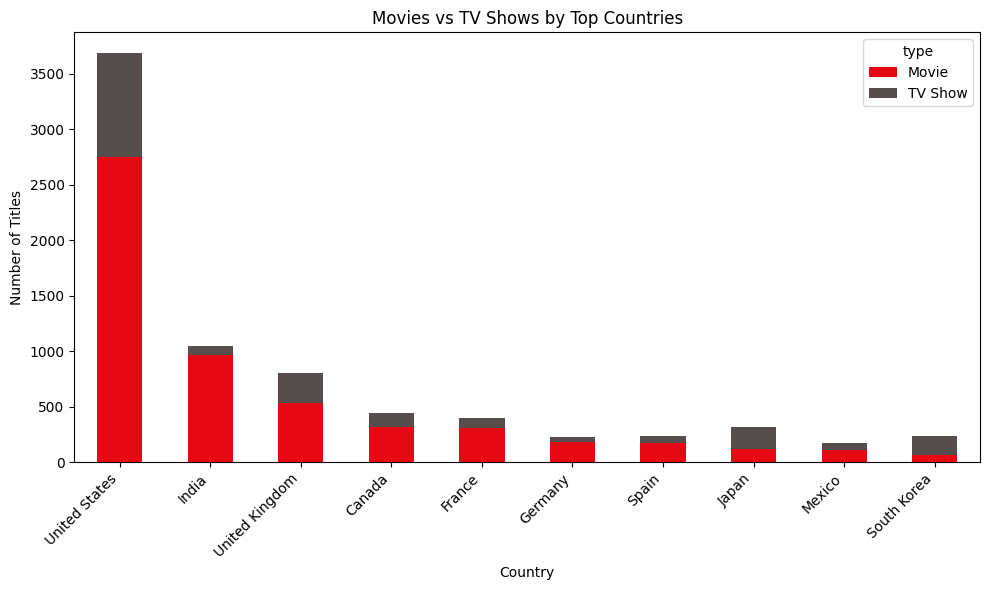

In [ ]:
# Plot a stacked bar chart showing Movies vs TV Shows for the top countries
country_type_top.sort_values(by='Movie', ascending=False).plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=[netflix_red, mid_gray]
)

plt.title("Movies vs TV Shows by Top Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability

plt.tight_layout()
plt.show()

Most top countries produce more Movies than TV Shows, though some (e.g., Japan, South Korea) show relatively stronger TV Show representation.

Netflix’s catalog is highly concentrated in a few major production markets, with strong dominance by the U.S. However, content type specialization varies across countries.

### Geographic Diversification Over Time

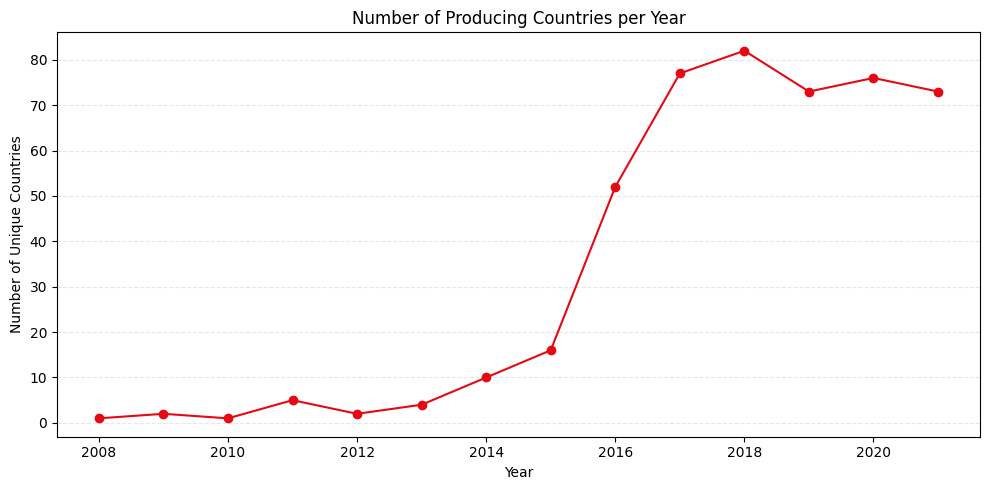

In [ ]:
# Count the number of unique producing countries per year, excluding 'Unknown'
country_per_year = (
    df_country_exploded[df_country_exploded['country'] != 'Unknown']
    .groupby('date_added_year')['country']
    .nunique()
    .dropna()
)

# Plot the number of unique countries added per year
country_per_year.plot(kind='line', color=netflix_red, marker='o', figsize=(10, 5))
plt.title("Number of Producing Countries per Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Countries")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The number of producing countries increases sharply after 2015.

The peak occurs around 2018–2019.

After that, diversification stabilizes at a high level.

Netflix underwent a major globalization phase after 2015, significantly expanding its international production network. The platform moved from a concentrated market structure to a globally diversified catalog.

### U.S. Dominance Over Time

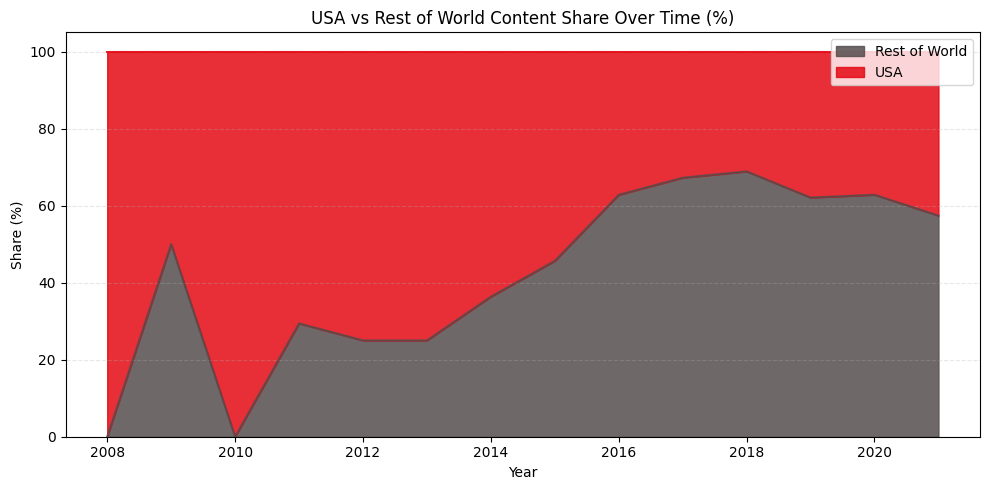

In [ ]:
# Create a copy of the exploded country DataFrame, excluding 'Unknown' countries
df_year_country = df_country_exploded[df_country_exploded['country'] != 'Unknown'].copy()

# Categorize countries into 'USA' or 'Rest of World'
us_vs_world = (
    df_year_country
    .assign(region=lambda x: x['country'].apply(lambda c: 'USA' if c == 'United States' else 'Rest of World'))
    .groupby(['date_added_year', 'region'])
    .size()
    .unstack(fill_value=0)
)
# Calculate the percentage share of USA vs Rest of World content over time
us_vs_world_pct = us_vs_world.div(us_vs_world.sum(axis=1), axis=0) * 100

# Plot a stacked area chart to visualize the content share of USA vs Rest of World
us_vs_world_pct.plot(kind='area', figsize=(10, 5), color=[mid_gray, netflix_red], alpha=0.85)
plt.title("USA vs Rest of World Content Share Over Time (%)")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The U.S. initially dominates almost entirely.

After 2015, the share of the Rest of the World increases substantially.

By 2018–2020, non-U.S. content reaches a much larger share.

While the U.S. remains the largest contributor, Netflix significantly increased international content acquisition, reducing relative dependence on American production.

### Fastest Growing Countries

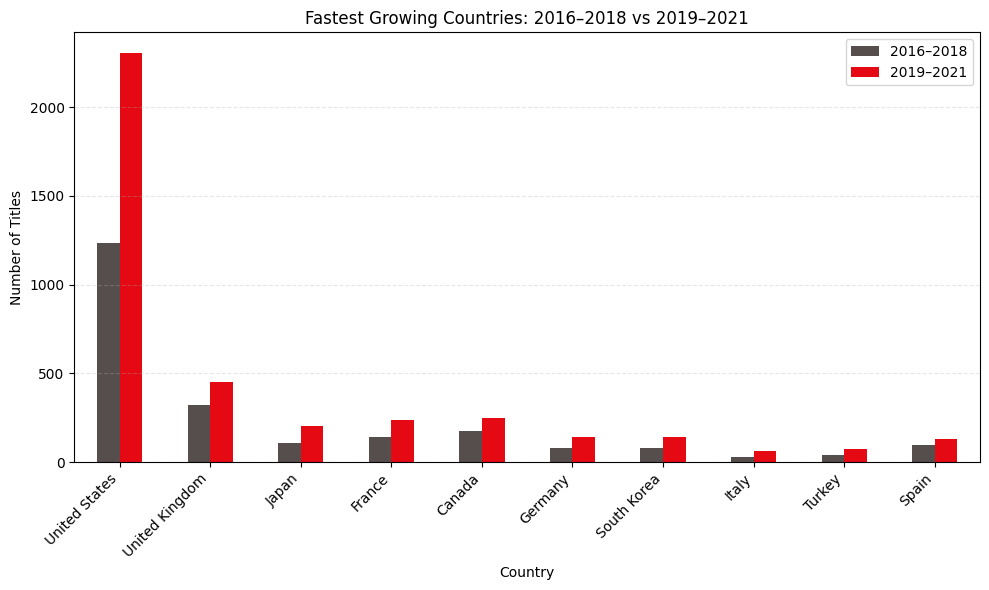

In [ ]:
# Count country contributions for an early period (2016-2018)
early = df_year_country[df_year_country['date_added_year'].between(2016, 2018)]['country'].value_counts()
# Count country contributions for a later period (2019-2021)
late  = df_year_country[df_year_country['date_added_year'].between(2019, 2021)]['country'].value_counts()

# Create a DataFrame to compare 'early' and 'late' contributions
growth = (
    pd.DataFrame({'early': early, 'late': late})
    .fillna(0) # Fill NaN values with 0 for countries not present in a period
    .assign(growth=lambda x: x['late'] - x['early']) # Calculate growth as difference
    .query('early >= 10')  # Filter out countries with very low initial contributions to focus on meaningful growth
    .nlargest(10, 'growth') # Get the top 10 countries by growth
)

# Plot a bar chart showing 'early' and 'late' contributions for fastest growing countries
growth[['early', 'late']].plot(
    kind='bar', figsize=(10, 6), color=[mid_gray, netflix_red]
)
plt.title("Fastest Growing Countries: 2016–2018 vs 2019–2021")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.legend(['2016–2018', '2019–2021'])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The United States still grows strongly in absolute numbers.

However, countries such as Japan, France, South Korea, and Spain show notable growth acceleration.

Growth is no longer limited to traditional Western markets.

Recent expansion is increasingly driven by international markets, indicating strategic investment in localized and regional production.

###
**Block 3 Conclusion**

Netflix’s catalog remains concentrated in a small group of leading countries, particularly the United States. However, after 2015 the platform significantly expanded its geographic footprint, increasing both the number of producing countries and the share of international content. While U.S. dominance persists in absolute terms, relative dependence has decreased as global markets play a growing role in content production.

## **Content Structure & Depth (Block 4)**

Key Questions:

* What is the structural runtime pattern of Netflix movies?

* How deep are Netflix TV productions in terms of seasons?

* Do Movies and TV Shows differ structurally in genre composition?

### Movie Duration Structure

In [ ]:
# Display descriptive statistics for 'duration_minutes' of movies
movies['duration_minutes'].describe()

,duration_minutes
count,6131.0
mean,99.564998
std,28.289504
min,3.0
25%,87.0
50%,98.0
75%,114.0
max,312.0


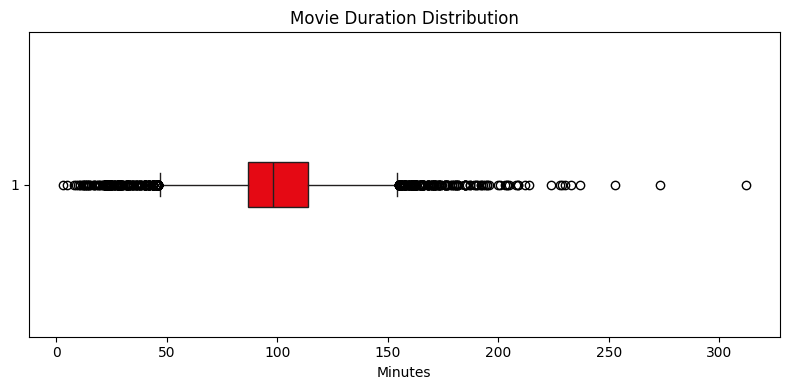

In [ ]:
plt.figure(figsize=(8,4))

# Create a box plot to visualize the distribution of movie durations
plt.boxplot(
    movies['duration_minutes'],
    vert=False, # Horizontal box plot
    patch_artist=True, # Fill boxes with color
    boxprops=dict(facecolor=netflix_red, color=dark_gray),
    medianprops=dict(color=dark_gray),
    whiskerprops=dict(color=dark_gray),
    capprops=dict(color=dark_gray)
)

plt.title("Movie Duration Distribution", fontsize=12)
plt.xlabel("Minutes")

plt.tight_layout()
plt.show()

Mean ≈ 99.6 minutes; Median = 98 minutes.

Interquartile range ≈ 87–114 minutes.

Only 19 films exceed 200 minutes (<0.3%).

Netflix strongly concentrates around the standard 90–110 minute feature-length format. Extreme long-form films exist but have negligible structural impact.

### TV Show Structural Depth

In [ ]:
# Display descriptive statistics for 'duration_seasons' of TV shows
tv_shows['duration_seasons'].describe()

,duration_seasons
count,2676.0
mean,1.764948
std,1.582752
min,1.0
25%,1.0
50%,1.0
75%,2.0
max,17.0


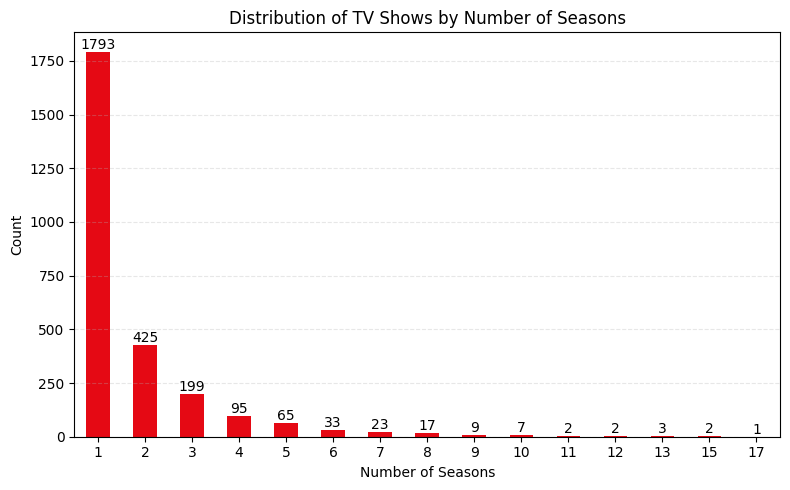

In [ ]:
# Count the occurrences of each number of seasons for TV shows and sort by season number
season_counts = tv_shows['duration_seasons'].value_counts().sort_index()

# Create a bar plot to visualize the distribution of TV shows by number of seasons
plt.figure(figsize=(8,5))
season_counts.plot(kind='bar', color=netflix_red)

# Add value labels on top of each bar
for i, value in enumerate(season_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.title('Distribution of TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the percentage of TV shows with only one season
one_season_percentage = (
    (tv_shows['duration'] == '1 Season').mean() * 100
)

# Display the calculated percentage
one_season_percentage

np.float64(67.00298953662183)

Average = 1.76 seasons; Median = 1 season.

~67% of shows are single-season.

Very few exceed 5 seasons; maximum = 17 seasons.

Netflix strongly favors short-form or limited-series production. Long-running series exist but are structurally marginal.

### Genre Structure by Content Type

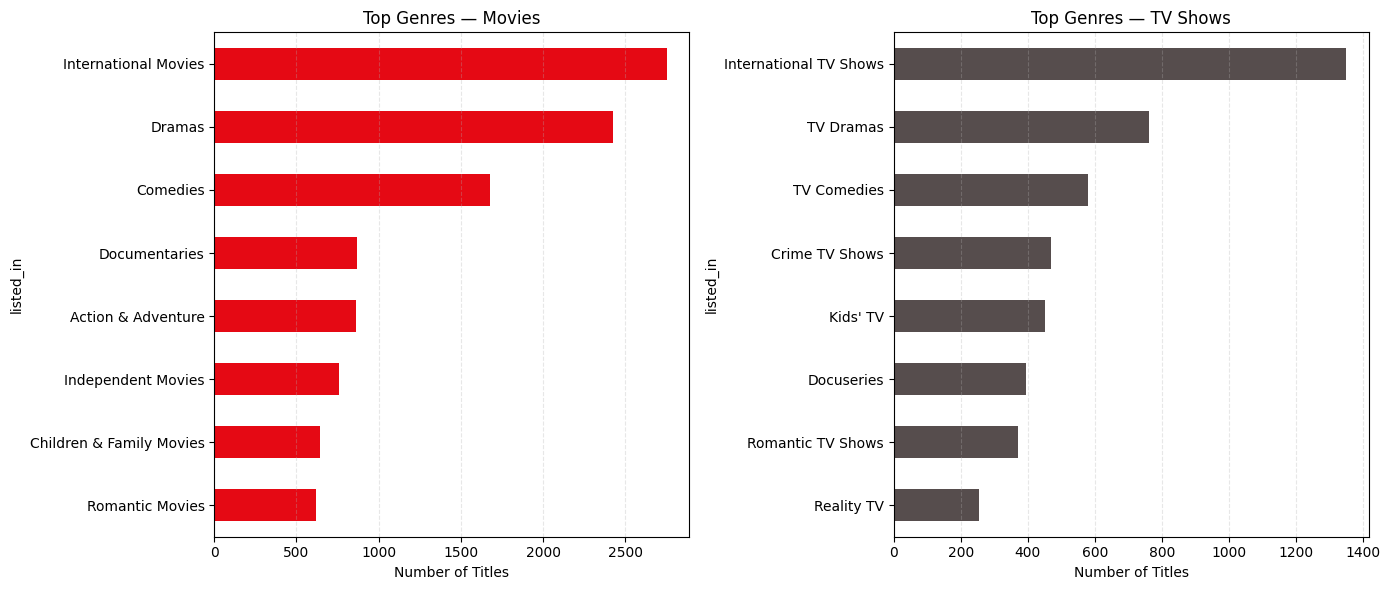

In [ ]:
# Create a copy of the DataFrame and split 'listed_in' column into individual genres, then explode
df_genre = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')

# Get the top 8 most frequent genres for movies
top_movie_genres = (
    df_genre[df_genre['type'] == 'Movie']['listed_in']
    .value_counts()
    .head(8)
)

# Get the top 8 most frequent genres for TV shows
top_tv_genres = (
    df_genre[df_genre['type'] == 'TV Show']['listed_in']
    .value_counts()
    .head(8)
)

# Create two subplots for movie and TV show genres
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot top movie genres as a horizontal bar chart
top_movie_genres.sort_values().plot(kind='barh', color=netflix_red, ax=ax1)
ax1.set_title("Top Genres — Movies")
ax1.set_xlabel("Number of Titles")

# Plot top TV show genres as a horizontal bar chart
top_tv_genres.sort_values().plot(kind='barh', color=mid_gray, ax=ax2)
ax2.set_title("Top Genres — TV Shows")
ax2.set_xlabel("Number of Titles")

# Add grid lines for better readability
ax1.grid(axis='x', linestyle='--', alpha=0.3)
ax2.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Movies and TV Shows on Netflix operate in almost entirely separate genre ecosystems. The "International" tag leads both lists, confirming Netflix's strong push toward non-English content across both formats. Movies have a much sharp drop-off after the top 3 genres, while TV Shows show a more even distribution across categories — suggesting a broader, more diversified content strategy for series. Notably, Documentaries appear as a top movie genre, whereas the TV equivalent (Docuseries) ranks lower, hinting that long-form documentary storytelling is more common in film format on the platform.

###
**Block 4 Conclusion**

Netflix maintains structural consistency in runtime format while diversifying thematically. Movies overwhelmingly follow conventional feature-length standards, and TV Shows are predominantly short-run or limited series. Genre composition further reveals format specialization: Movies prioritize cinematic storytelling, while TV Shows concentrate on serialized and recurring narrative structures.

## **Acquisition & Production Pattern (Block 5)**

Key Questions:

* Is Netflix’s production network concentrated among a few directors or distributed across many?

* Does Netflix rely on recurring cast networks?

* How collaborative and internationally co-produced is Netflix content?

### Director Concentration

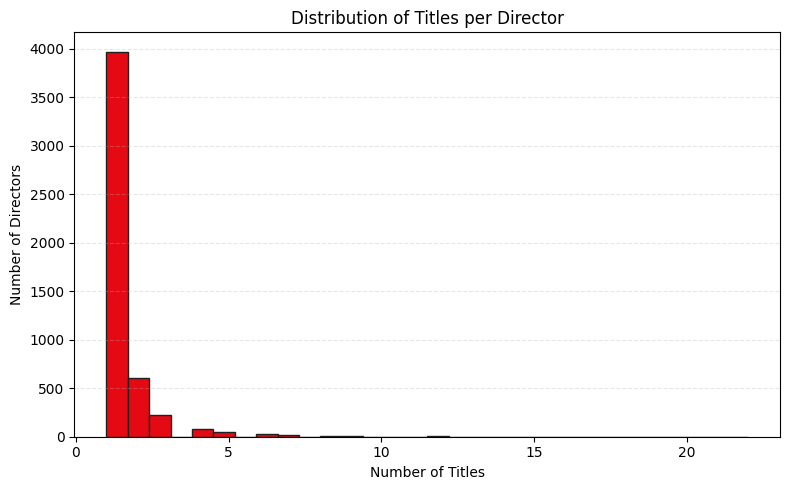

In [ ]:

# Prepare DataFrame by splitting 'director' column and exploding into multiple rows
df_director = (df[df['director'] != 'Unknown']
    .assign(director=df['director'].str.split(', '))
    .explode('director'))
# Count the number of titles each director has contributed
director_counts = df_director['director'].value_counts()

# Create a histogram to visualize the distribution of titles per director
plt.figure(figsize=(8, 5))
plt.hist(director_counts, bins=30, color=netflix_red, edgecolor=dark_gray)
plt.title("Distribution of Titles per Director")
plt.xlabel("Number of Titles")
plt.ylabel("Number of Directors")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


The distribution of titles per director clearly follows a long-tail pattern. Most directors appear only once in the dataset, while only a small number are associated with multiple titles. This indicates that the platform does not rely heavily on a limited group of recurring directors, but instead operates with a highly diversified creative base. Such a structure suggests a strong acquisition-driven model rather than centralized in-house production.

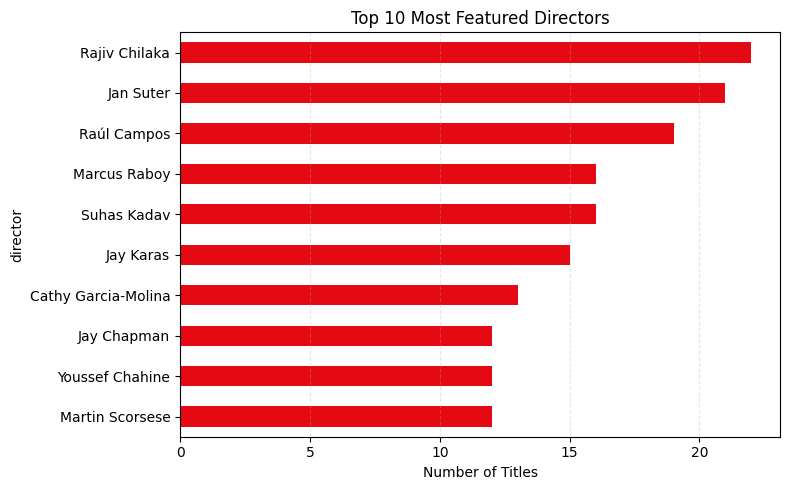

In [ ]:

# Plot the top 10 most featured directors as a horizontal bar chart
director_counts.head(10).sort_values().plot(kind='barh', color=netflix_red, figsize=(8, 5))
plt.title("Top 10 Most Featured Directors")
plt.xlabel("Number of Titles")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Although there are directors with 15–20 titles, none of them dominate the catalog in a structurally significant way. This further reinforces the idea that content sourcing is distributed and decentralized.

### Actor Concentration

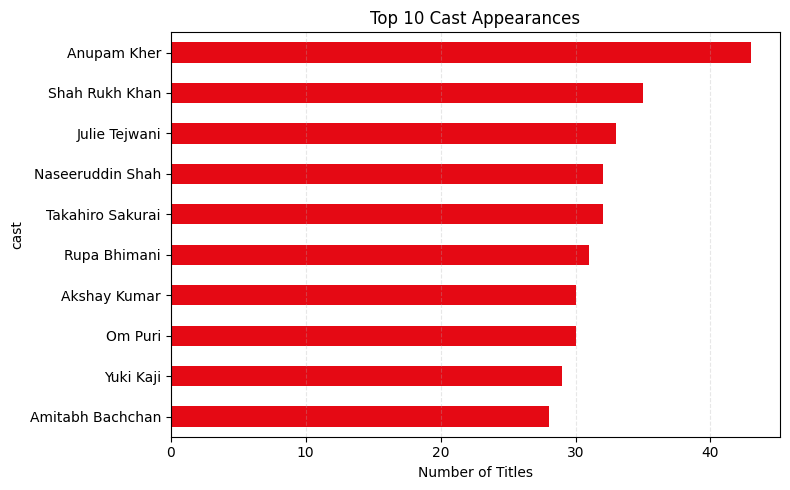

In [ ]:
# Prepare DataFrame by splitting 'cast' column and exploding into multiple rows
df_cast = (df[df['cast'] != 'Unknown']
    .assign(cast=df['cast'].str.split(', '))
    .explode('cast'))
# Count the number of titles each actor has appeared in
actor_counts = df_cast['cast'].value_counts()

# Plot the top 10 cast appearances as a horizontal bar chart
actor_counts.head(10).sort_values().plot(kind='barh', color=netflix_red, figsize=(8, 5))
plt.title("Top 10 Cast Appearances")
plt.xlabel("Number of Titles")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Some actors are featured in a large number of titles, which likely reflects regional industry structures rather than platform-driven repetition. This suggests that content is often acquired in blocks from specific national markets where certain actors frequently collaborate across productions.

### Multi-Country Production Structure

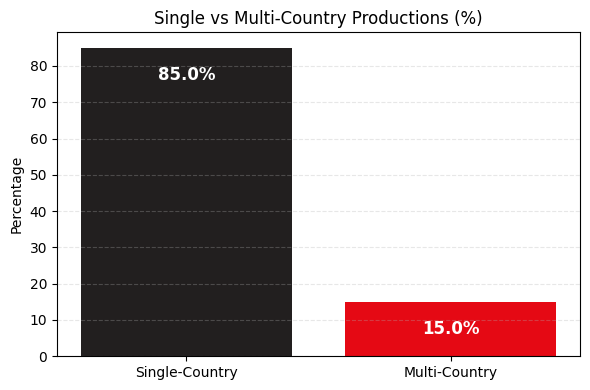

In [ ]:
# Calculate the percentage of multi-country productions
multi_pct = df['country'].apply(lambda x: ',' in str(x)).mean() * 100
# Create a list for single vs multi-country percentages
single_vs_multi = [100 - multi_pct, multi_pct]

# Create a bar chart to show the proportion of single vs multi-country productions
plt.figure(figsize=(6, 4))
bars = plt.bar(["Single-Country", "Multi-Country"], single_vs_multi, color=[dark_gray, netflix_red])
# Add percentage labels to the bars
for bar, val in zip(bars, single_vs_multi):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 5,
             f'{val:.1f}%', ha='center', va='top', fontsize=12, fontweight='bold', color='white')
plt.title("Single vs Multi-Country Productions (%)")
plt.ylabel("Percentage")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In terms of geographic production structure, the vast majority of titles are single-country productions, while only a small percentage represent multi-country collaborations. This shows that, despite being globally distributed, the platform’s content is primarily locally produced. Global diversity is achieved through catalog aggregation rather than international co-production strategies.

###
Overall, the production architecture appears decentralized, acquisition-focused, and globally distributed but locally sourced.

# 4. Conclusions


**Netflix's catalog is built for scale, not franchises.**

Across every dimension analyzed — duration, format, genre, and production — the data tells a consistent story: Netflix optimizes for breadth and volume rather than depth and concentration.


---


**Format discipline.** Movies cluster tightly around the 90–110 minute theatrical standard with minimal deviation, signaling a deliberate acquisition filter. TV content tells the opposite story — 67% of shows run a single season, revealing a platform that favors limited-series formats over long-running commitments. The result: faster content refresh, lower production risk, and a catalog built for binge consumption rather than franchise loyalty.

**Genre as a global strategy.** "International" leads both movie and TV genre rankings — not as a niche, but as the dominant category. Drama forms the backbone across both formats, while documentaries and crime content add depth. This is not genre specialization; it is a deliberate positioning as a globally diverse, broadly appealing platform that serves many audiences simultaneously rather than any single one deeply.

**Decentralized by design.** Director contributions follow a classic long-tail distribution — thousands of directors with one or two titles each. Most productions are single-country. No single creative voice or production hub dominates. This architecture scales through wide acquisition across markets, not through centralized studio control.

---

**The bottom line:** Netflix operates as a globally distributed, locally sourced streaming aggregator. The catalog prioritizes diversity, moderate risk exposure, and volume — a scale-driven model where breadth of choice *is* the product.